# Tuberculosis Trends and Health-System Vulnerability in Libya

## Case Study Overview

This case study examines changes in the tuberculosis burden in Libya and explores how migration, displacement, conflict, and limitations in health-system capacity may relate to the observed patterns.

The analysis will use publicly available data from credible international organizations. It will identify trends and relationships without assuming that migration or any single factor directly caused changes in tuberculosis incidence.

## Ask

### Public Health Task

A public-health organization wants to better understand how the tuberculosis burden in Libya has changed over time. The organization has requested an analysis of TB indicators alongside available migration, displacement, conflict, and health-system indicators.

The objective is to identify important trends, possible relationships, gaps in the available data, and areas requiring stronger surveillance or public-health intervention.

### Main Research Question

How has the tuberculosis burden in Libya changed over time, and how might migration, displacement, conflict, and health-system limitations relate to the observed trends?

### Supporting Questions

1. How have TB incidence, reported cases, mortality, and estimated case detection rate changed in Libya?
2. How have migrant, refugee, and internally displaced population estimates changed during the same period?
3. Do changes in these contextual indicators coincide with changes in Libya’s TB burden?
4. What health-system or surveillance limitations could affect TB prevention, detection, treatment, and reporting?
5. What public-health actions could be considered based on the findings?

### Key Metrics

* Estimated TB incidence per 100,000 people
* Number of notified or reported TB cases
* Estimated TB deaths or mortality rate
* TB estimated case detection rate and treatment success, where available
* Estimated migrant population
* Refugee and internally displaced population estimates
* Selected health-system capacity or service-availability indicators
* Data availability and completeness

### Stakeholders

* Libya’s Ministry of Health
* Libya’s National Centre for Disease Control
* World Health Organization
* International Organization for Migration
* Humanitarian and refugee-support organizations
* Healthcare professionals and public-health researchers

### Intended Audience

The primary audience consists of public-health officials, health-program managers, epidemiologists, humanitarian organizations, and other decision-makers involved in tuberculosis surveillance, prevention, and treatment in Libya.

### How the Analysis Can Support Decisions

The findings may help stakeholders recognize changes in TB burden, identify vulnerable populations and surveillance gaps, prioritize prevention and screening activities, and determine where additional data collection or health-system support may be needed.


In [65]:
from pathlib import Path
import pandas as pd

# Find all CSV files attached to this Kaggle notebook
csv_files = list(Path("/kaggle/input").rglob("*.csv"))

print("CSV files found:")
for file in csv_files:
    print(file.name)

CSV files found:
TB_notifications_2026-09-12.csv
TB_burden_countries_2026-09-12.csv
TB_data_dictionary_2026-09-12.csv


## Prepare

### Importing the WHO Tuberculosis Data

The analysis uses WHO-generated tuberculosis burden estimates, country-reported case notifications, and the accompanying WHO data dictionary.

In [66]:
# Locate each WHO dataset
burden_file = next(Path("/kaggle/input").rglob("TB_burden_countries*.csv"))
notifications_file = next(Path("/kaggle/input").rglob("TB_notifications*.csv"))
dictionary_file = next(Path("/kaggle/input").rglob("TB_data_dictionary*.csv"))

# Load the CSV files into pandas DataFrames
burden = pd.read_csv(burden_file)
notifications = pd.read_csv(notifications_file)
data_dictionary = pd.read_csv(dictionary_file)

# Display the dimensions of each dataset
print("TB burden dataset:", burden.shape)
print("TB notifications dataset:", notifications.shape)
print("Data dictionary:", data_dictionary.shape)

TB burden dataset: (5347, 50)
TB notifications dataset: (9567, 216)
Data dictionary: (698, 4)


In [67]:
# Filter both datasets to Libya using the ISO3 country code
libya_burden = burden[burden["iso3"] == "LBY"].copy()
libya_notifications = notifications[
    notifications["iso3"] == "LBY"
].copy()

# Sort the records chronologically
libya_burden = libya_burden.sort_values("year")
libya_notifications = libya_notifications.sort_values("year")

print("Libya burden records:", libya_burden.shape)
print(
    "Burden years:",
    libya_burden["year"].min(),
    "to",
    libya_burden["year"].max()
)

print("\nLibya notification records:", libya_notifications.shape)
print(
    "Notification years:",
    libya_notifications["year"].min(),
    "to",
    libya_notifications["year"].max()
)

Libya burden records: (25, 50)
Burden years: 2000 to 2024

Libya notification records: (45, 216)
Notification years: 1980 to 2024


In [68]:
# Select the main TB indicators and WHO uncertainty bounds
burden_columns = [
    "year",
    "e_pop_num",
    "e_inc_100k",
    "e_inc_100k_lo",
    "e_inc_100k_hi",
    "e_inc_num",
    "e_mort_100k",
    "e_mort_100k_lo",
    "e_mort_100k_hi",
    "e_mort_num",
    "c_newinc_100k",
    "c_cdr"
]

libya_tb = libya_burden[burden_columns].copy()

# Add the number of cases officially notified by Libya
reported_cases = libya_notifications[
    ["year", "c_newinc"]
].copy()

libya_tb = libya_tb.merge(
    reported_cases,
    on="year",
    how="left",
    validate="one_to_one"
)

# Give the columns clear, portfolio-friendly names
libya_tb = libya_tb.rename(columns={
    "e_pop_num": "population",
    "e_inc_100k": "estimated_incidence_per_100k",
    "e_inc_100k_lo": "incidence_lower_bound",
    "e_inc_100k_hi": "incidence_upper_bound",
    "e_inc_num": "estimated_tb_cases",
    "e_mort_100k": "estimated_mortality_per_100k",
    "e_mort_100k_lo": "mortality_lower_bound",
    "e_mort_100k_hi": "mortality_upper_bound",
    "e_mort_num": "estimated_tb_deaths",
    "c_newinc_100k": "notification_rate_per_100k",
    "c_cdr": "estimated_case_detection_rate_pct",
    "c_newinc": "reported_tb_cases"
})

# Confirm that the uncertainty-bound columns were added
display(
    libya_tb[[
        "year",
        "estimated_incidence_per_100k",
        "incidence_lower_bound",
        "incidence_upper_bound",
        "estimated_mortality_per_100k",
        "mortality_lower_bound",
        "mortality_upper_bound"
    ]].tail()
)

,year,estimated_incidence_per_100k,incidence_lower_bound,incidence_upper_bound,estimated_mortality_per_100k,mortality_lower_bound,mortality_upper_bound
20,2020,43.0,26.0,85.0,8.7,3.4,16.0
21,2021,47.0,28.0,96.0,9.5,3.8,18.0
22,2022,52.0,31.0,108.0,10.0,4.6,19.0
23,2023,57.0,33.0,123.0,12.0,5.7,21.0
24,2024,63.0,36.0,138.0,13.0,6.1,21.0


In [69]:
# Check for duplicate years
duplicate_years = libya_tb["year"].duplicated().sum()

# Create a data-quality summary
quality_report = pd.DataFrame({
    "data_type": libya_tb.dtypes.astype(str),
    "missing_values": libya_tb.isna().sum(),
    "unique_values": libya_tb.nunique()
})

print("Duplicate years:", duplicate_years)
print("Total rows:", len(libya_tb))
print("Expected rows for 2000–2024:", 25)

display(quality_report)

Duplicate years: 0
Total rows: 25
Expected rows for 2000–2024: 25


,data_type,missing_values,unique_values
year,int64,0,25
population,int64,0,25
estimated_incidence_per_100k,float64,0,19
incidence_lower_bound,float64,0,17
incidence_upper_bound,float64,0,23
estimated_tb_cases,float64,0,18
estimated_mortality_per_100k,float64,0,17
mortality_lower_bound,float64,0,24
mortality_upper_bound,float64,0,16
estimated_tb_deaths,float64,0,21


In [70]:
# Identify the years containing missing reported-data values
reported_columns = [
    "notification_rate_per_100k",
    "estimated_case_detection_rate_pct",
    "reported_tb_cases"
]

missing_reported_data = libya_tb[
    libya_tb[reported_columns].isna().any(axis=1)
][["year"] + reported_columns]

display(missing_reported_data)

,year,notification_rate_per_100k,estimated_case_detection_rate_pct,reported_tb_cases
1,2001,NaN,NaN,NaN
10,2010,NaN,NaN,NaN


### Initial Data-Quality Assessment

The WHO tuberculosis datasets were filtered to Libya using the ISO3 country code `LBY`. The burden and notification datasets were then sorted by year and merged using the year as the common key.

The main analysis period is 2000–2024 because WHO burden estimates are available for all 25 years in this period. The following checks were performed:

- All 25 expected annual records were present.
- No duplicate years were identified.
- Estimated incidence and mortality variables contained no missing values.
- Reported TB cases, the notification rate, and estimated case detection rate were missing for 2001 and 2010.
- These two years were retained because other TB indicators remained available.
- Missing values were not replaced or estimated to avoid introducing unsupported information.
- Clearer column names were created to improve readability and reproducibility.

### IOM Migration Context Data

Annual migrant-population estimates were manually compiled from official IOM Displacement Tracking Matrix reports. The latest reporting round covering the end of each year was selected where available.

These figures represent migrants identified by IOM DTM and should not be interpreted as exact population counts. Differences between years may reflect changes in population movement, geographic coverage, access, and data-collection methods.

In [71]:
# Annual migrant estimates extracted from official IOM DTM reports
migration_data = pd.DataFrame({
    "year": [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    
    "migrants_identified": [
        621706,
        663455,
        654081,
        571464,
        635051,
        694398,
        706509,
        824131
    ],
    
    "iom_round": [
        16, 23, 28, 34, 40, 45, 50, 55
    ],
    
    "reporting_period": [
        "December 2017",
        "November–December 2018",
        "October–December 2019",
        "November–December 2020",
        "December 2021–January 2022",
        "November–December 2022",
        "October–December 2023",
        "November–December 2024"
    ],
    
    "source_url": [
        "https://dtm.iom.int/reports/libya-%E2%80%94-migrant-report-16-december-2017",
        "https://dtm.iom.int/reports/libya-migrant-report-23-nov-dec-2018",
        "https://dtm.iom.int/reports/migrant-report-key-findings-round-28-oct-dec-2019",
        "https://dtm.iom.int/reports/libya-migrant-report-34-november-december-2020",
        "https://dtm.iom.int/reports/libya-migrant-report-40-dec-2021-jan-2022",
        "https://dtm.iom.int/reports/libya-migrant-report-45-november-december-2022",
        "https://dtm.iom.int/reports/libya-migrant-report-50-october-december-2023",
        "https://dtm.iom.int/reports/libya-migrant-report-55-november-december-2024"
    ]
})

display(migration_data)

,year,migrants_identified,iom_round,reporting_period,source_url
0,2017,621706,16,December 2017,https://dtm.iom.int/reports/libya-%E2%80%94-mi...
1,2018,663455,23,November–December 2018,https://dtm.iom.int/reports/libya-migrant-repo...
2,2019,654081,28,October–December 2019,https://dtm.iom.int/reports/migrant-report-key...
3,2020,571464,34,November–December 2020,https://dtm.iom.int/reports/libya-migrant-repo...
4,2021,635051,40,December 2021–January 2022,https://dtm.iom.int/reports/libya-migrant-repo...
5,2022,694398,45,November–December 2022,https://dtm.iom.int/reports/libya-migrant-repo...
6,2023,706509,50,October–December 2023,https://dtm.iom.int/reports/libya-migrant-repo...
7,2024,824131,55,November–December 2024,https://dtm.iom.int/reports/libya-migrant-repo...


In [72]:
# Merge the TB indicators with the IOM migration estimates
tb_migration = libya_tb.merge(
    migration_data,
    on="year",
    how="inner",
    validate="one_to_one"
)

# Calculate migrants identified as a percentage of Libya's population
tb_migration["migrants_pct_population"] = (
    tb_migration["migrants_identified"]
    / tb_migration["population"]
    * 100
)

# Display the variables needed for the contextual analysis
display(
    tb_migration[[
        "year",
        "estimated_incidence_per_100k",
        "estimated_tb_cases",
        "reported_tb_cases",
        "estimated_mortality_per_100k",
        "estimated_case_detection_rate_pct",
        "migrants_identified",
        "migrants_pct_population"
    ]].round(2)
)

,year,estimated_incidence_per_100k,estimated_tb_cases,reported_tb_cases,estimated_mortality_per_100k,estimated_case_detection_rate_pct,migrants_identified,migrants_pct_population
0,2017,34.0,2300.0,1363.0,6.9,59.0,621706,9.23
1,2018,37.0,2500.0,1815.0,5.3,72.0,663455,9.69
2,2019,40.0,2800.0,2215.0,4.3,80.0,654081,9.41
3,2020,43.0,3000.0,1748.0,8.7,57.0,571464,8.11
4,2021,47.0,3400.0,1944.0,9.5,58.0,635051,8.90
5,2022,52.0,3800.0,2168.0,10.0,58.0,694398,9.61
6,2023,57.0,4200.0,2318.0,12.0,55.0,706509,9.67
7,2024,63.0,4700.0,2712.0,13.0,58.0,824131,11.17


## Process

### Data Transformation and Derived Indicators

The WHO burden and notification datasets were joined by year after filtering both sources to Libya. The IOM migration estimates were then merged with the corresponding TB records for 2017–2024.

Two derived indicators were calculated:

- **Estimated case-detection gap:** the difference between WHO-estimated TB cases and officially reported TB cases.
- **Reported share of estimated cases:** reported TB cases divided by WHO-estimated TB cases, expressed as a percentage.

The case-detection gap may include cases that were undiagnosed, unreported, or otherwise absent from official notifications. It should therefore be interpreted as an estimate rather than an exact count of undiagnosed people.

In [73]:
# Calculate the estimated gap between incident and reported TB cases
libya_tb["estimated_case_detection_gap"] = (
    libya_tb["estimated_tb_cases"]
    - libya_tb["reported_tb_cases"]
)

# Calculate the reported share of WHO-estimated incident cases
libya_tb["reported_share_estimated_pct"] = (
    libya_tb["reported_tb_cases"]
    / libya_tb["estimated_tb_cases"]
    * 100
)

# Recreate the contextual table with the new indicators
tb_migration = libya_tb.merge(
    migration_data,
    on="year",
    how="inner",
    validate="one_to_one"
)

tb_migration["migrants_pct_population"] = (
    tb_migration["migrants_identified"]
    / tb_migration["population"]
    * 100
)

display(
    tb_migration[[
        "year",
        "estimated_tb_cases",
        "reported_tb_cases",
        "estimated_case_detection_gap",
        "reported_share_estimated_pct",
        "estimated_case_detection_rate_pct"
    ]].round(1)
)

,year,estimated_tb_cases,reported_tb_cases,estimated_case_detection_gap,reported_share_estimated_pct,estimated_case_detection_rate_pct
0,2017,2300.0,1363.0,937.0,59.3,59.0
1,2018,2500.0,1815.0,685.0,72.6,72.0
2,2019,2800.0,2215.0,585.0,79.1,80.0
3,2020,3000.0,1748.0,1252.0,58.3,57.0
4,2021,3400.0,1944.0,1456.0,57.2,58.0
5,2022,3800.0,2168.0,1632.0,57.1,58.0
6,2023,4200.0,2318.0,1882.0,55.2,55.0
7,2024,4700.0,2712.0,1988.0,57.7,58.0


In [74]:
# Compare our calculated percentage with WHO's treatment-coverage estimate
coverage_validation = tb_migration[[
    "year",
    "reported_share_estimated_pct",
    "estimated_case_detection_rate_pct"
]].copy()

coverage_validation["difference_percentage_points"] = (
    coverage_validation["reported_share_estimated_pct"]
    - coverage_validation["estimated_case_detection_rate_pct"]
)

display(coverage_validation.round(2))

print(
    "Largest absolute difference:",
    round(
        coverage_validation[
            "difference_percentage_points"
        ].abs().max(),
        2
    ),
    "percentage points"
)

,year,reported_share_estimated_pct,estimated_case_detection_rate_pct,difference_percentage_points
0,2017,59.26,59.0,0.26
1,2018,72.60,72.0,0.60
2,2019,79.11,80.0,-0.89
3,2020,58.27,57.0,1.27
4,2021,57.18,58.0,-0.82
5,2022,57.05,58.0,-0.95
6,2023,55.19,55.0,0.19
7,2024,57.70,58.0,-0.30


Largest absolute difference: 1.27 percentage points


In [75]:
# Export the cleaned datasets for reproducibility
libya_tb.to_csv(
    "/kaggle/working/libya_tb_clean_2000_2024.csv",
    index=False
)

migration_data.to_csv(
    "/kaggle/working/libya_iom_migration_2017_2024.csv",
    index=False
)

tb_migration.to_csv(
    "/kaggle/working/libya_tb_migration_merged_2017_2024.csv",
    index=False
)

print("Cleaned files exported successfully:")
print("- libya_tb_clean_2000_2024.csv")
print("- libya_iom_migration_2017_2024.csv")
print("- libya_tb_migration_merged_2017_2024.csv")

Cleaned files exported successfully:
- libya_tb_clean_2000_2024.csv
- libya_iom_migration_2017_2024.csv
- libya_tb_migration_merged_2017_2024.csv


## Analyze

### Changes in Key Tuberculosis and Migration Indicators

Percentage and absolute changes were calculated to evaluate long-term TB trends from 2000 to 2024 and the overlapping TB–migration period from 2017 to 2024.

In [76]:
def calculate_change(data, column, start_year, end_year, label):
    start_value = data.loc[
        data["year"] == start_year, column
    ].iloc[0]
    
    end_value = data.loc[
        data["year"] == end_year, column
    ].iloc[0]
    
    return {
        "indicator": label,
        "period": f"{start_year}–{end_year}",
        "start_value": start_value,
        "end_value": end_value,
        "absolute_change": end_value - start_value,
        "percent_change": (
            (end_value - start_value) / start_value * 100
        )
    }


change_summary = pd.DataFrame([
    calculate_change(
        libya_tb,
        "estimated_incidence_per_100k",
        2000,
        2024,
        "Estimated TB incidence per 100,000"
    ),
    calculate_change(
        libya_tb,
        "estimated_mortality_per_100k",
        2000,
        2024,
        "Estimated TB mortality per 100,000"
    ),
    calculate_change(
        libya_tb,
        "estimated_tb_cases",
        2000,
        2024,
        "Estimated TB cases"
    ),
    calculate_change(
        tb_migration,
        "reported_tb_cases",
        2017,
        2024,
        "Reported TB cases"
    ),
    calculate_change(
        tb_migration,
        "estimated_case_detection_gap",
        2017,
        2024,
        "Estimated case-detection gap"
    ),
    calculate_change(
        tb_migration,
        "migrants_identified",
        2017,
        2024,
        "Migrants identified by IOM"
    )
])

display(change_summary.round(1))

,indicator,period,start_value,end_value,absolute_change,percent_change
0,"Estimated TB incidence per 100,000",2000–2024,59.0,63.0,4.0,6.8
1,"Estimated TB mortality per 100,000",2000–2024,15.0,13.0,-2.0,-13.3
2,Estimated TB cases,2000–2024,3100.0,4700.0,1600.0,51.6
3,Reported TB cases,2017–2024,1363.0,2712.0,1349.0,99.0
4,Estimated case-detection gap,2017–2024,937.0,1988.0,1051.0,112.2
5,Migrants identified by IOM,2017–2024,621706.0,824131.0,202425.0,32.6


In [77]:
recent_change_summary = pd.DataFrame([
    calculate_change(
        libya_tb,
        "estimated_incidence_per_100k",
        2019,
        2024,
        "Estimated TB incidence per 100,000"
    ),
    calculate_change(
        libya_tb,
        "estimated_mortality_per_100k",
        2019,
        2024,
        "Estimated TB mortality per 100,000"
    ),
    calculate_change(
        libya_tb,
        "estimated_tb_cases",
        2019,
        2024,
        "Estimated TB cases"
    ),
    calculate_change(
        libya_tb,
        "reported_tb_cases",
        2019,
        2024,
        "Reported TB cases"
    ),
    calculate_change(
        libya_tb,
        "estimated_case_detection_gap",
        2019,
        2024,
        "Estimated case-detection gap"
    )
])

# estimated case detection rate is best expressed as a percentage-point change
coverage_2019 = libya_tb.loc[
    libya_tb["year"] == 2019,
    "estimated_case_detection_rate_pct"
].iloc[0]

coverage_2024 = libya_tb.loc[
    libya_tb["year"] == 2024,
    "estimated_case_detection_rate_pct"
].iloc[0]

display(recent_change_summary.round(1))

print(
    "estimated case detection rate change:",
    coverage_2019,
    "% in 2019 to",
    coverage_2024,
    "% in 2024"
)

print(
    "Percentage-point change:",
    round(coverage_2024 - coverage_2019, 1)
)

,indicator,period,start_value,end_value,absolute_change,percent_change
0,"Estimated TB incidence per 100,000",2019–2024,40.0,63.0,23.0,57.5
1,"Estimated TB mortality per 100,000",2019–2024,4.3,13.0,8.7,202.3
2,Estimated TB cases,2019–2024,2800.0,4700.0,1900.0,67.9
3,Reported TB cases,2019–2024,2215.0,2712.0,497.0,22.4
4,Estimated case-detection gap,2019–2024,585.0,1988.0,1403.0,239.8


estimated case detection rate change: 80.0 % in 2019 to 58.0 % in 2024
Percentage-point change: -22.0


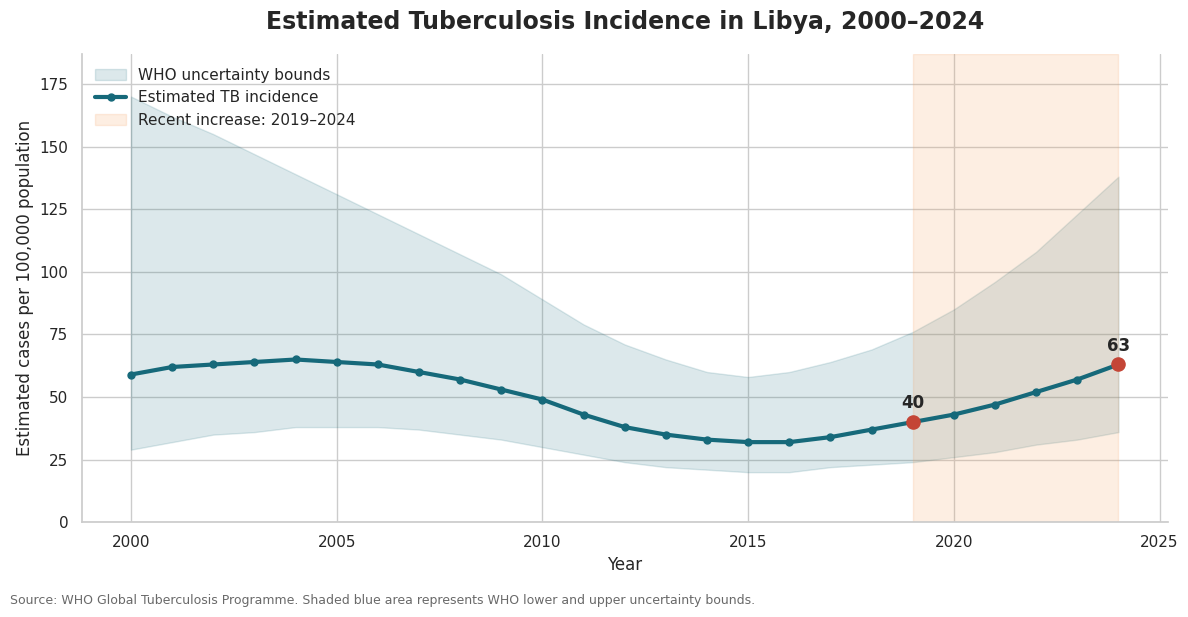

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent visual style
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

# Show WHO lower and upper uncertainty bounds
ax.fill_between(
    libya_tb["year"],
    libya_tb["incidence_lower_bound"],
    libya_tb["incidence_upper_bound"],
    color="#16697A",
    alpha=0.15,
    label="WHO uncertainty bounds"
)

# Plot annual estimated TB incidence
ax.plot(
    libya_tb["year"],
    libya_tb["estimated_incidence_per_100k"],
    color="#16697A",
    linewidth=3,
    marker="o",
    markersize=5,
    label="Estimated TB incidence"
)

# Highlight the recent period
ax.axvspan(
    2019,
    2024,
    color="#F4A261",
    alpha=0.18,
    label="Recent increase: 2019–2024"
)

# Highlight and label the 2019 and 2024 estimates
for year in [2019, 2024]:
    value = libya_tb.loc[
        libya_tb["year"] == year,
        "estimated_incidence_per_100k"
    ].iloc[0]

    ax.scatter(
        year,
        value,
        color="#C44536",
        s=90,
        zorder=5
    )

    ax.annotate(
        f"{value:.0f}",
        (year, value),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontweight="bold"
    )

ax.set_title(
    "Estimated Tuberculosis Incidence in Libya, 2000–2024",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel(
    "Estimated cases per 100,000 population",
    fontsize=12
)

# Use the upper uncertainty bound to prevent the band from being cut off
ax.set_ylim(
    0,
    libya_tb["incidence_upper_bound"].max() * 1.1
)

ax.legend(
    frameon=False,
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    -0.02,
    "Source: WHO Global Tuberculosis Programme. "
    "Shaded blue area represents WHO lower and upper uncertainty bounds.",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/chart_1_tb_incidence_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 1: TB Incidence Reversed Its Earlier Decline

Estimated TB incidence declined from the early 2000s and reached its lowest level of approximately 32 cases per 100,000 population in 2015–2016. This improvement did not continue. Incidence subsequently increased every year, reaching 63 per 100,000 in 2024.

Between 2019 and 2024, estimated incidence increased by 57.5%. The trend demonstrates a substantial recent deterioration, although the country-level data alone cannot identify its causes.

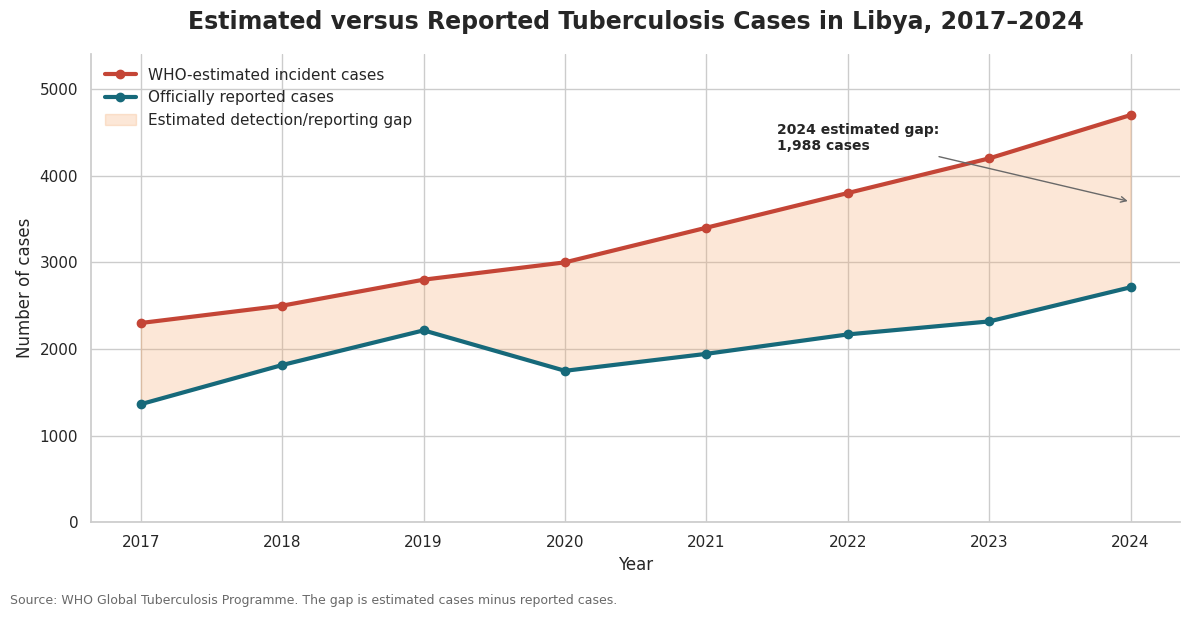

In [79]:
# Use years with complete reported-case data
case_gap_data = libya_tb[
    (libya_tb["year"] >= 2017)
    & (libya_tb["year"] <= 2024)
].copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    case_gap_data["year"],
    case_gap_data["estimated_tb_cases"],
    color="#C44536",
    linewidth=3,
    marker="o",
    label="WHO-estimated incident cases"
)

ax.plot(
    case_gap_data["year"],
    case_gap_data["reported_tb_cases"],
    color="#16697A",
    linewidth=3,
    marker="o",
    label="Officially reported cases"
)

# Shade the estimated detection gap
ax.fill_between(
    case_gap_data["year"],
    case_gap_data["reported_tb_cases"],
    case_gap_data["estimated_tb_cases"],
    color="#F4A261",
    alpha=0.25,
    label="Estimated detection/reporting gap"
)

gap_2024 = case_gap_data.loc[
    case_gap_data["year"] == 2024,
    "estimated_case_detection_gap"
].iloc[0]

ax.annotate(
    f"2024 estimated gap:\n{gap_2024:,.0f} cases",
    xy=(2024, 3700),
    xytext=(2021.5, 4300),
    arrowprops=dict(arrowstyle="->", color="dimgray"),
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "Estimated versus Reported Tuberculosis Cases in Libya, 2017–2024",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of cases", fontsize=12)
ax.set_ylim(0, case_gap_data["estimated_tb_cases"].max() * 1.15)
ax.legend(frameon=False, loc="upper left")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    -0.02,
    "Source: WHO Global Tuberculosis Programme. The gap is estimated cases minus reported cases.",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/chart_2_tb_detection_gap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 2: The Estimated Case-Detection Gap Widened

WHO-estimated incident TB cases increased from 2,800 in 2019 to 4,700 in 2024, while officially reported cases increased from 2,215 to 2,712.

As a result, the estimated difference between incident and reported cases increased from 585 cases in 2019 to 1,988 cases in 2024. Over the same period, WHO-estimated case detection rate declined from 80% to 58%.

This gap does not prove that every missing case was undiagnosed. However, it suggests a growing challenge in detecting, treating, or reporting the full estimated TB burden.

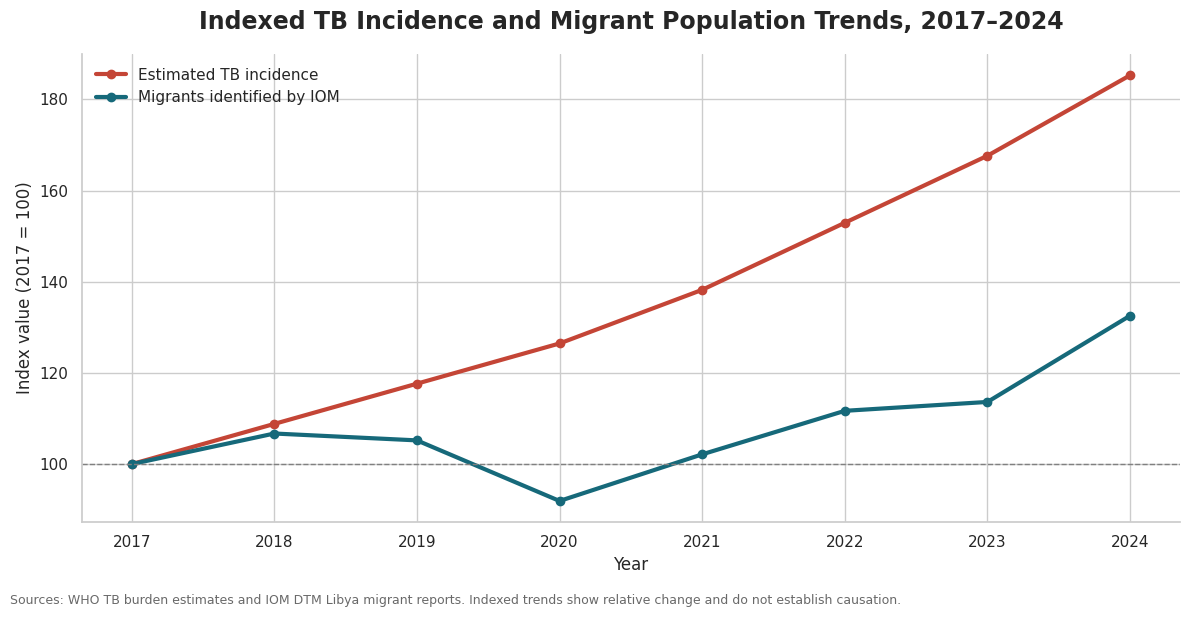

In [80]:
# Index both variables to 2017 = 100 for a fair trend comparison
trend_comparison = tb_migration[[
    "year",
    "estimated_incidence_per_100k",
    "migrants_identified"
]].copy()

trend_comparison["tb_incidence_index"] = (
    trend_comparison["estimated_incidence_per_100k"]
    / trend_comparison["estimated_incidence_per_100k"].iloc[0]
    * 100
)

trend_comparison["migration_index"] = (
    trend_comparison["migrants_identified"]
    / trend_comparison["migrants_identified"].iloc[0]
    * 100
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    trend_comparison["year"],
    trend_comparison["tb_incidence_index"],
    color="#C44536",
    linewidth=3,
    marker="o",
    label="Estimated TB incidence"
)

ax.plot(
    trend_comparison["year"],
    trend_comparison["migration_index"],
    color="#16697A",
    linewidth=3,
    marker="o",
    label="Migrants identified by IOM"
)

ax.axhline(
    100,
    color="gray",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Indexed TB Incidence and Migrant Population Trends, 2017–2024",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Index value (2017 = 100)", fontsize=12)
ax.legend(frameon=False, loc="upper left")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    -0.02,
    "Sources: WHO TB burden estimates and IOM DTM Libya migrant reports. "
    "Indexed trends show relative change and do not establish causation.",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/chart_3_tb_migration_indexed_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
from scipy.stats import pearsonr, spearmanr

correlation_data = tb_migration[[
    "migrants_identified",
    "estimated_incidence_per_100k"
]].dropna()

pearson_r, pearson_p = pearsonr(
    correlation_data["migrants_identified"],
    correlation_data["estimated_incidence_per_100k"]
)

spearman_r, spearman_p = spearmanr(
    correlation_data["migrants_identified"],
    correlation_data["estimated_incidence_per_100k"]
)

print("Number of yearly observations:", len(correlation_data))
print(
    f"Pearson correlation: r = {pearson_r:.3f}, "
    f"p = {pearson_p:.3f}"
)
print(
    f"Spearman correlation: rho = {spearman_r:.3f}, "
    f"p = {spearman_p:.3f}"
)

Number of yearly observations: 8
Pearson correlation: r = 0.785, p = 0.021
Spearman correlation: rho = 0.714, p = 0.047


In [82]:
# Calculate annual changes to reduce the influence of shared time trends
annual_changes = tb_migration[[
    "year",
    "migrants_identified",
    "estimated_incidence_per_100k"
]].copy()

annual_changes["change_in_migrants"] = (
    annual_changes["migrants_identified"].diff()
)

annual_changes["change_in_tb_incidence"] = (
    annual_changes["estimated_incidence_per_100k"].diff()
)

change_data = annual_changes.dropna()

change_pearson_r, change_pearson_p = pearsonr(
    change_data["change_in_migrants"],
    change_data["change_in_tb_incidence"]
)

change_spearman_r, change_spearman_p = spearmanr(
    change_data["change_in_migrants"],
    change_data["change_in_tb_incidence"]
)

display(
    change_data[[
        "year",
        "change_in_migrants",
        "change_in_tb_incidence"
    ]]
)

print(
    f"Pearson correlation of annual changes: "
    f"r = {change_pearson_r:.3f}, p = {change_pearson_p:.3f}"
)

print(
    f"Spearman correlation of annual changes: "
    f"rho = {change_spearman_r:.3f}, p = {change_spearman_p:.3f}"
)

,year,change_in_migrants,change_in_tb_incidence
1,2018,41749.0,3.0
2,2019,-9374.0,3.0
3,2020,-82617.0,3.0
4,2021,63587.0,4.0
5,2022,59347.0,5.0
6,2023,12111.0,5.0
7,2024,117622.0,6.0


Pearson correlation of annual changes: r = 0.706, p = 0.076
Spearman correlation of annual changes: rho = 0.711, p = 0.073


### Finding 3: Migration and TB Increased During the Same Period, but Causation Cannot Be Established

From 2017 to 2024, the number of migrants identified by IOM increased by 32.6%, while estimated TB incidence increased more rapidly.

The unadjusted annual levels were positively correlated (Pearson r = 0.785, p = 0.021; Spearman ρ = 0.714, p = 0.047). However, both indicators also increased over time.

After examining year-to-year changes, the associations were no longer statistically significant at the 0.05 level (Pearson p = 0.076; Spearman p = 0.073). The analysis includes only seven annual changes and cannot account for conflict, healthcare access, COVID-19 disruption, poverty, living conditions, or changes in data collection.

Therefore, the findings show that TB incidence and migrant estimates increased during an overlapping period, but they do not demonstrate that migration caused the increase in TB.

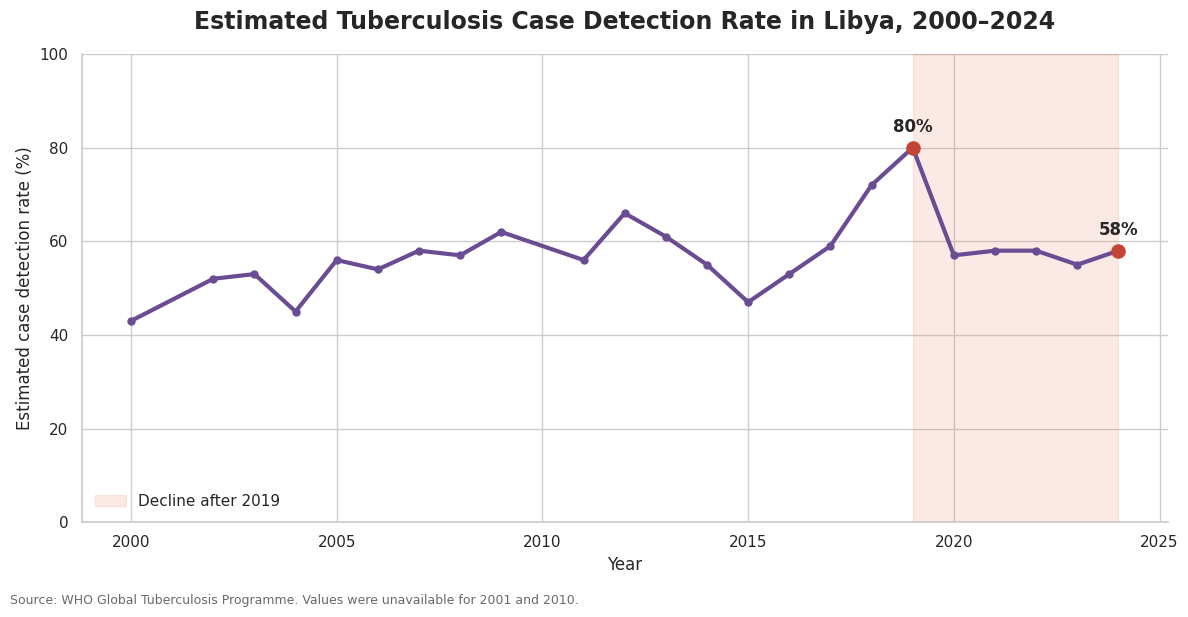

In [83]:
coverage_data = libya_tb.dropna(
    subset=["estimated_case_detection_rate_pct"]
).copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    coverage_data["year"],
    coverage_data["estimated_case_detection_rate_pct"],
    color="#6A4C93",
    linewidth=3,
    marker="o",
    markersize=5
)

ax.axvspan(
    2019,
    2024,
    color="#E76F51",
    alpha=0.15,
    label="Decline after 2019"
)

for year in [2019, 2024]:
    value = coverage_data.loc[
        coverage_data["year"] == year,
        "estimated_case_detection_rate_pct"
    ].iloc[0]
    
    ax.scatter(year, value, color="#C44536", s=90, zorder=5)
    ax.annotate(
        f"{value:.0f}%",
        (year, value),
        xytext=(0, 11),
        textcoords="offset points",
        ha="center",
        fontweight="bold"
    )

ax.set_title(
    "Estimated Tuberculosis Case Detection Rate in Libya, 2000–2024",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Estimated case detection rate (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.legend(frameon=False, loc="lower left")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    -0.02,
    "Source: WHO Global Tuberculosis Programme. Values were unavailable for 2001 and 2010.",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/chart_4_tb_treatment_coverage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 4: The Estimated Case Detection Rate Fell and Did Not Recover to Its 2019 Level

WHO’s estimated TB case detection rate increased to 80% in 2019 but dropped to 57% in 2020. The rate remained between approximately 55% and 58% from 2020 through 2024.

By 2024, the estimated case detection rate remained 22 percentage points below its 2019 level. This persistent shortfall coincided with increases in estimated TB incidence, mortality, and the case-detection gap, indicating continued pressure on TB detection and treatment services.

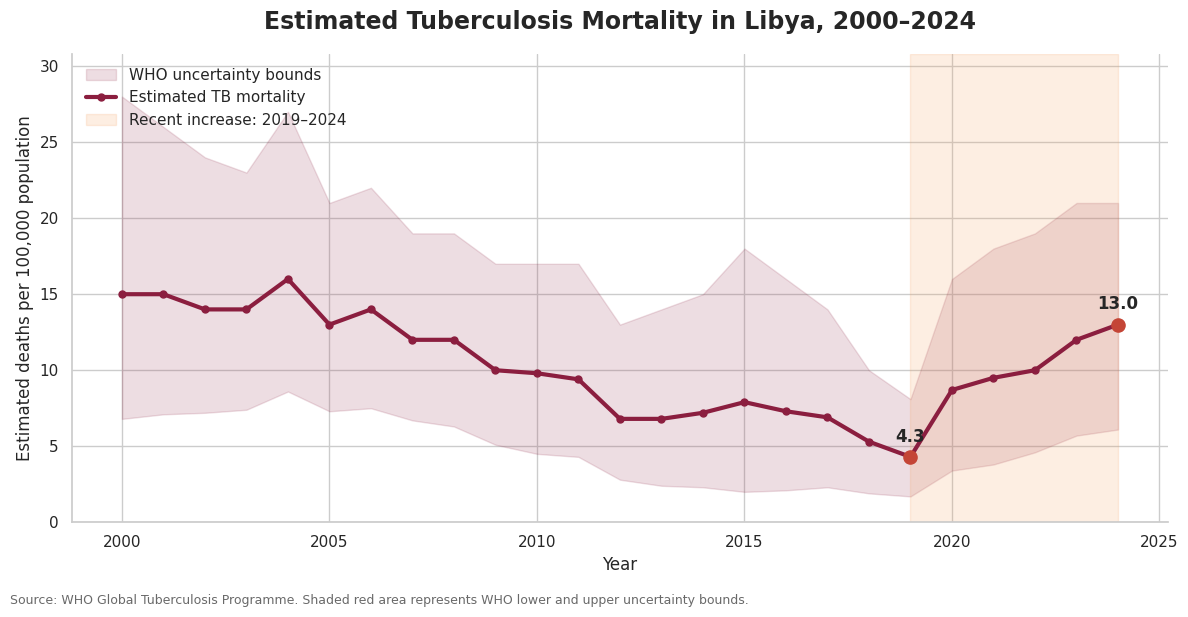

In [84]:
fig, ax = plt.subplots(figsize=(12, 6))

# Show WHO lower and upper uncertainty bounds
ax.fill_between(
    libya_tb["year"],
    libya_tb["mortality_lower_bound"],
    libya_tb["mortality_upper_bound"],
    color="#8B1E3F",
    alpha=0.15,
    label="WHO uncertainty bounds"
)

# Plot annual estimated TB mortality
ax.plot(
    libya_tb["year"],
    libya_tb["estimated_mortality_per_100k"],
    color="#8B1E3F",
    linewidth=3,
    marker="o",
    markersize=5,
    label="Estimated TB mortality"
)

# Highlight the recent period
ax.axvspan(
    2019,
    2024,
    color="#F4A261",
    alpha=0.18,
    label="Recent increase: 2019–2024"
)

# Highlight and label the 2019 and 2024 estimates
for year in [2019, 2024]:
    value = libya_tb.loc[
        libya_tb["year"] == year,
        "estimated_mortality_per_100k"
    ].iloc[0]

    ax.scatter(
        year,
        value,
        color="#C44536",
        s=90,
        zorder=5
    )

    ax.annotate(
        f"{value:.1f}",
        (year, value),
        xytext=(0, 11),
        textcoords="offset points",
        ha="center",
        fontweight="bold"
    )

ax.set_title(
    "Estimated Tuberculosis Mortality in Libya, 2000–2024",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel(
    "Estimated deaths per 100,000 population",
    fontsize=12
)

# Use the upper uncertainty bound so the band is not cut off
ax.set_ylim(
    0,
    libya_tb["mortality_upper_bound"].max() * 1.1
)

ax.legend(
    frameon=False,
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    -0.02,
    "Source: WHO Global Tuberculosis Programme. "
    "Shaded red area represents WHO lower and upper uncertainty bounds.",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/chart_5_tb_mortality_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 5: Estimated TB Mortality Increased Sharply After 2019

Estimated TB mortality declined for much of the study period and reached 4.3 deaths per 100,000 population in 2019. It then increased each year, reaching 13.0 deaths per 100,000 in 2024.

This represents a 202.3% increase between 2019 and 2024. The simultaneous rise in mortality and incidence, together with a lower estimated case detection rate and a widening case-detection gap, suggests increasing pressure on Libya’s TB prevention, diagnosis, and treatment system.


## Share

### Key Findings

1. **The earlier decline in TB incidence reversed.** Estimated incidence fell until 2015–2016 but subsequently increased to 63 cases per 100,000 population in 2024.

2. **The recent increase was substantial.** Between 2019 and 2024, estimated incidence increased by 57.5%, estimated cases increased by 67.9%, and estimated mortality increased by 202.3%.

3. **Reported cases did not keep pace with the estimated burden.** From 2019 to 2024, reported cases increased by 22.4%, compared with a 67.9% increase in WHO-estimated incident cases.

4. **The estimated case-detection gap widened.** The difference between estimated and reported cases increased from 585 in 2019 to 1,988 in 2024.

5. ** Estimated case detection rate remained below its 2019 level.** WHO-estimated case detection rate declined from 80% in 2019 to 58% in 2024.

6. **Migration and TB incidence increased during an overlapping period.** The unadjusted levels were positively correlated, but the annual-change correlations were not statistically significant at the 0.05 level.

7. **The available ecological data cannot establish causation.** The results do not demonstrate that migrants caused Libya’s increase in TB. Migration may interact with overcrowding, disrupted care, poverty, displacement, conflict, and barriers to healthcare, but individual-level or subnational evidence would be required to test these pathways.

### Current Context Beyond the TB Study Period

The WHO TB dataset used in this analysis ends in 2024. More recent IOM data show that 943,748 migrants were identified across Libya during March–April 2026. This figure was not included in the statistical analysis because corresponding 2025–2026 WHO TB data were unavailable.

Source: [IOM DTM Libya Migrant Report 62](https://dtm.iom.int/reports/libya-migrant-report-62-march-april-2026)

### Limitations

These correlation analyses are exploratory and hypothesis-generating. With only eight annual observations—and seven observations for annual changes—the coefficients and p-values are unstable. Pearson correlation assumes an approximately linear relationship and is sensitive to influential observations. In addition, annual observations may not be independent. Spearman correlation requires fewer distributional assumptions but remains imprecise with this small sample. Neither analysis accounts for shared time trends, autocorrelation, confounding factors, changes in IOM data coverage, or possible lagged effects. Therefore, the results indicate co-movement only and do not establish that migration caused changes in tuberculosis incidence.

---

## Act

### Public-Health Recommendations

1. **Strengthen active TB case finding.** Expand accessible screening and diagnostic services in areas with high estimated case-detection gaps.

2. **Investigate and address the drop in case detection.** Determine why the estimated case detection rate fell from 80% in 2019 to below 60% after 2020, and address barriers affecting diagnosis, case notification, treatment initiation, adherence, and continuity of care.

3. **Provide inclusive services for vulnerable populations.** Ensure that migrants, refugees, internally displaced people, and underserved host communities can access confidential TB screening and treatment without stigma or discrimination.

4. **Improve surveillance quality.** Strengthen timely case notification, laboratory reporting, treatment monitoring, and secure collection of relevant demographic and geographic information.
5. **Use subnational data for resource allocation.** Future analyses should compare TB burden, migration, displacement, and healthcare capacity across municipalities to identify priority locations.

6. **Maintain TB services during emergencies.** Develop continuity plans for conflict, displacement, disease outbreaks, and other disruptions that may interrupt diagnosis or treatment.

7. **Conduct further epidemiological research.** Individual-level or carefully designed subnational studies are needed to assess the independent effects of migration, displacement, living conditions, and healthcare access on TB risk.

### Conclusion

Libya experienced a substantial deterioration in major TB indicators after 2019. By 2024, incidence and mortality had increased, the estimated case detection rate remained below its earlier level, and the estimated difference between incident and reported cases had widened.

Migration estimates also increased during part of this period, but the available national-level data cannot establish that migration caused the rise in TB. The most defensible interpretation is that Libya faces a growing TB burden within a complex context of population mobility, displacement, service disruption, and health-system constraints.

The priority should be stronger surveillance, inclusive screening, reliable diagnosis, treatment continuity, and better subnational data—not stigmatizing mobile or displaced populations.